# Pythagorean Expectation for the NFL
Fit the exponent `k` in  **Win% = PF^k / (PF^k + PA^k)**  using every regular-season game since 1999.
Ties count as half a win. Fit via a binomial GLM: `logit(p) = k * log(PF/PA)` (optionally with an intercept `α`).

In [1]:
import numpy as np, pandas as pd, statsmodels.api as sm
import matplotlib.pyplot as plt
import nfl_data_py as nfl
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.spines.top": False, "axes.spines.right": False})

## 1. Data: one row per team-season

In [2]:
games = nfl.import_schedules(range(1999, 2026))
games = games[(games.game_type == "REG")].dropna(subset=["home_score", "away_score"])

home = games.assign(team=games.home_team, pf=games.home_score, pa=games.away_score)
away = games.assign(team=games.away_team, pf=games.away_score, pa=games.home_score)
long = pd.concat([home, away])[["season", "team", "pf", "pa"]].copy()
long["w"] = (long.pf > long.pa) + 0.5 * (long.pf == long.pa)
long["gp"] = 1

t = long.groupby(["season", "team"], as_index=False)[["pf", "pa", "w", "gp"]].sum()
t["wpct"] = t.w / t.gp
t["x"] = np.log(t.pf / t.pa)
print(len(games), "games ->", len(t), "team-seasons")
t.head()

6967 games -> 861 team-seasons


,season,team,pf,pa,w,gp,wpct,x
0,1999,ARI,245.0,382.0,6.0,16,0.3750,-0.444162
1,1999,ATL,285.0,380.0,5.0,16,0.3125,-0.287682
2,1999,BAL,324.0,277.0,8.0,16,0.5000,0.156726
3,1999,BUF,320.0,229.0,11.0,16,0.6875,0.334599
4,1999,CAR,421.0,381.0,8.0,16,0.5000,0.099833


## 2. Fit `k` (no intercept) and test whether an intercept is needed

In [3]:
def fit(df, intercept=False):
    X = sm.add_constant(df[["x"]]) if intercept else df[["x"]]
    return sm.GLM(df.wpct, X, family=sm.families.Binomial(), freq_weights=df.gp).fit()

m0 = fit(t); m1 = fit(t, intercept=True)
print(m0.summary().tables[1]); print(m1.summary().tables[1])
print(f"k (no intercept) = {m0.params['x']:.3f}   |   k = {m1.params['x']:.3f}, alpha = {m1.params['const']:.3f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x              2.6657      0.069     38.798      0.000       2.531       2.800
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0128      0.018      0.709      0.478      -0.023       0.048
x              2.6661      0.069     38.809      0.000       2.531       2.801
k (no intercept) = 2.666   |   k = 2.666, alpha = 0.013


### Bootstrap confidence interval for `k` (resampling team-seasons)

In [4]:
rng = np.random.default_rng(0)
ks = [fit(t.sample(len(t), replace=True, random_state=int(rng.integers(1e9)))).params["x"] for _ in range(500)]
lo, hi = np.percentile(ks, [2.5, 97.5])
print(f"k = {m0.params['x']:.3f}, 95% bootstrap CI [{lo:.3f}, {hi:.3f}]  (published benchmark: 2.37)")

k = 2.666, 95% bootstrap CI [2.568, 2.767]  (published benchmark: 2.37)


## 3. Out-of-sample accuracy (train 1999–2019, test 2020–2025)

In [5]:
train, test = t[t.season <= 2019], t[t.season >= 2020].copy()
mt = fit(train)
k_fit = mt.params["x"]
print("k fit on train:", round(k_fit, 3))

def expected_wins(df, k):
    return df.gp * df.pf**k / (df.pf**k + df.pa**k)

def score(pred, actual):
    e = pred - actual
    return pd.Series({"MAE": e.abs().mean(), "RMSE": np.sqrt((e**2).mean())})

# scale naive baseline to game count so 16 vs 17 game seasons compare fairly
res = pd.DataFrame({
    f"Fitted k={k_fit:.2f}": score(expected_wins(test, k_fit), test.w),
    "Benchmark k=2.37":      score(expected_wins(test, 2.37), test.w),
    "Baseline: .500 team":   score(test.gp / 2, test.w),
    "Baseline: 1.83 (MLB)":  score(expected_wins(test, 1.83), test.w),
}).T
res.round(3)

k fit on train: 2.625


,MAE,RMSE
Fitted k=2.62,1.111,1.411
Benchmark k=2.37,1.158,1.458
Baseline: .500 team,2.656,3.193
Baseline: 1.83 (MLB),1.357,1.673


## 4. Fit quality

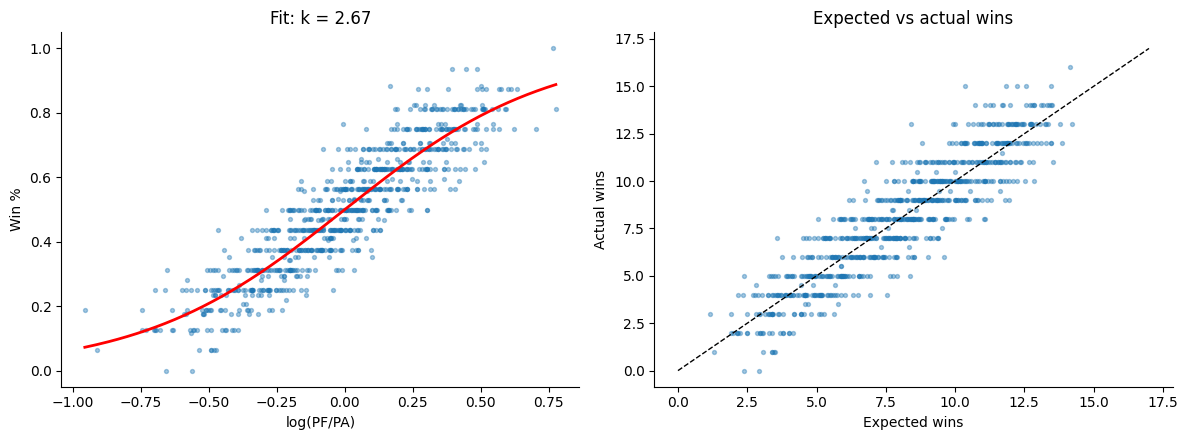

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
xs = np.linspace(t.x.min(), t.x.max(), 200)
ax[0].scatter(t.x, t.wpct, s=8, alpha=.4)
ax[0].plot(xs, 1/(1+np.exp(-m0.params["x"]*xs)), "r", lw=2)
ax[0].set(xlabel="log(PF/PA)", ylabel="Win %", title=f"Fit: k = {m0.params['x']:.2f}")

t["exp_w"] = expected_wins(t, m0.params["x"])
ax[1].scatter(t.exp_w, t.w, s=8, alpha=.4)
lim = [0, 17]; ax[1].plot(lim, lim, "k--", lw=1)
ax[1].set(xlabel="Expected wins", ylabel="Actual wins", title="Expected vs actual wins")
plt.tight_layout(); plt.show()

## 5. Over- and under-performers

In [7]:
t["diff"] = t.w - t.exp_w
cols = ["season", "team", "pf", "pa", "w", "exp_w", "diff"]
print("Most lucky (actual > expected)"); display(t.sort_values("diff", ascending=False)[cols].head(10).round(2))
print("Most unlucky (actual < expected)"); display(t.sort_values("diff")[cols].head(10).round(2))

Most lucky (actual > expected)


,season,team,pf,pa,w,exp_w,diff
812,2024,KC,385.0,326.0,15.0,10.35,4.65
753,2022,MIN,424.0,427.0,13.0,8.42,4.58
426,2012,IND,357.0,387.0,11.0,7.14,3.86
396,2011,KC,212.0,338.0,7.0,3.58,3.42
719,2021,LV,374.0,439.0,10.0,6.71,3.29
676,2020,CLE,408.0,419.0,11.0,7.72,3.28
684,2020,KC,473.0,362.0,14.0,10.74,3.26
564,2016,OAK,416.0,385.0,12.0,8.82,3.18
181,2004,PIT,372.0,251.0,15.0,11.85,3.15
648,2019,GB,376.0,313.0,13.0,9.92,3.08


Most unlucky (actual < expected)


,season,team,pf,pa,w,exp_w,diff
844,2025,KC,362.0,328.0,6.0,9.61,-3.61
670,2020,ATL,396.0,414.0,4.0,7.53,-3.53
86,2001,SD,332.0,321.0,5.0,8.36,-3.36
235,2006,JAX,371.0,274.0,8.0,11.07,-3.07
645,2019,DAL,434.0,321.0,8.0,11.05,-3.05
296,2008,GB,419.0,380.0,6.0,9.04,-3.04
319,2009,BAL,391.0,261.0,9.0,11.94,-2.94
580,2017,CLE,234.0,410.0,0.0,2.93,-2.93
852,2025,NYG,381.0,439.0,4.0,6.91,-2.91
186,2004,TB,301.0,304.0,5.0,7.89,-2.89


## 6. Does over-performance persist?
If the Pythagorean gap is mostly luck, a team's gap this season should say little about its gap next season, and expected wins should predict next season's record better than actual wins do.

In [8]:
nxt = t[["season", "team", "wpct", "diff", "gp"]].copy(); nxt["season"] -= 1
nxt = nxt.rename(columns={"wpct": "wpct_next", "diff": "diff_next", "gp": "gp_next"})
p = t.merge(nxt, on=["season", "team"])
p["exp_wpct"] = p.exp_w / p.gp
print("corr(gap this yr, gap next yr):", round(p["diff"].corr(p["diff_next"]), 3))
print("corr(actual win%   -> next win%):", round(p.wpct.corr(p.wpct_next), 3))
print("corr(expected win% -> next win%):", round(p.exp_wpct.corr(p.wpct_next), 3))

corr(gap this yr, gap next yr): 0.003
corr(actual win%   -> next win%): 0.329
corr(expected win% -> next win%): 0.363


## 7. Does the exponent drift over eras?

In [9]:
eras = {"1999-2008": (1999, 2008), "2009-2016": (2009, 2016), "2017-2025": (2017, 2025)}
for name, (a, b) in eras.items():
    d = t[t.season.between(a, b)]; f = fit(d)
    ci = f.conf_int().loc["x"]
    print(f"{name}: k = {f.params['x']:.3f}  (95% CI {ci[0]:.2f}-{ci[1]:.2f})")

1999-2008: k = 2.548  (95% CI 2.34-2.76)
2009-2016: k = 2.694  (95% CI 2.45-2.94)
2017-2025: k = 2.790  (95% CI 2.55-3.03)


## 8. Last completed season

In [10]:
cur = t[t.season == t.season.max()].copy()
cur["Expected W"] = expected_wins(cur, m0.params["x"])
cur[["team", "gp", "w", "Expected W", "pf", "pa"]].sort_values("Expected W", ascending=False).round(2).reset_index(drop=True)

,team,gp,w,Expected W,pf,pa
0,SEA,17,14.0,13.48,483.0,292.0
1,NE,17,14.0,12.87,490.0,320.0
2,LA,17,12.0,12.68,518.0,346.0
3,JAX,17,13.0,12.15,474.0,336.0
4,HOU,17,12.0,11.87,404.0,295.0
5,BUF,17,12.0,11.49,481.0,365.0
6,DEN,17,14.0,11.27,401.0,311.0
7,SF,17,12.0,10.33,437.0,371.0
8,PHI,17,11.0,10.22,379.0,325.0
9,DET,17,9.0,10.20,481.0,413.0


## 9. Weekly expected-wins tracker (in-progress season)
Uses the exponent fit on completed seasons only (`m0`, no look-ahead) and updates cumulative PF/PA week by week.
Early-season numbers are very noisy (a few games), so read the projection as a rough guide until ~week 8.

In [11]:
K = m0.params["x"]
TRACK = int(nfl.import_schedules([t.season.max() + 1]).season.max())
cg = nfl.import_schedules([TRACK])
cg = cg[cg.game_type == "REG"].dropna(subset=["home_score", "away_score"])
last_week = int(cg.week.max())

h = cg.assign(team=cg.home_team, pf=cg.home_score, pa=cg.away_score)
a = cg.assign(team=cg.away_team, pf=cg.away_score, pa=cg.home_score)
wk = pd.concat([h, a])[["week", "team", "pf", "pa"]].copy()
wk["w"] = (wk.pf > wk.pa) + 0.5 * (wk.pf == wk.pa)
wk["gp"] = 1

# cumulative through each week; bye weeks carry the previous total forward
grid = pd.MultiIndex.from_product([range(1, last_week + 1), sorted(wk.team.unique())], names=["week", "team"])
cum = (wk.groupby(["week", "team"])[["pf", "pa", "w", "gp"]].sum()
         .reindex(grid, fill_value=0).groupby("team").cumsum().reset_index())
cum["exp_w"] = expected_wins(cum, K).where(cum.gp > 0)
cum["exp_wpct"] = cum.exp_w / cum.gp
cum["gap"] = cum.w - cum.exp_w
print(f"{TRACK} season, through week {last_week}, k = {K:.3f}")

now = cum[cum.week == last_week].copy()
now["proj_w"] = now.exp_wpct * 17
tbl = now.sort_values("exp_w", ascending=False)[["team", "gp", "w", "exp_w", "gap", "pf", "pa", "proj_w"]]
tbl.columns = ["Team", "GP", "W", "Exp W", "W - Exp W", "PF", "PA", "Proj. wins (17 g)"]
tbl.round(2).reset_index(drop=True)

2026 season, through week 3, k = 2.666


,Team,GP,W,Exp W,W - Exp W,PF,PA,Proj. wins (17 g)
0,JAX,3,2.0,2.70,-0.70,82.0,36.0,15.30
1,SF,3,3.0,2.57,0.43,98.0,50.0,14.58
2,KC,3,3.0,2.46,0.54,88.0,50.0,13.92
3,MIN,3,3.0,2.44,0.56,71.0,41.0,13.81
4,CHI,3,2.0,2.40,-0.40,89.0,53.0,13.59
5,LV,3,3.0,2.36,0.64,88.0,54.0,13.36
6,SEA,3,2.0,2.24,-0.24,75.0,50.0,12.69
7,BUF,3,3.0,2.00,1.00,101.0,78.0,11.32
8,CIN,3,2.0,1.96,0.04,80.0,63.0,11.12
9,BAL,3,2.0,1.82,0.18,92.0,78.0,10.34


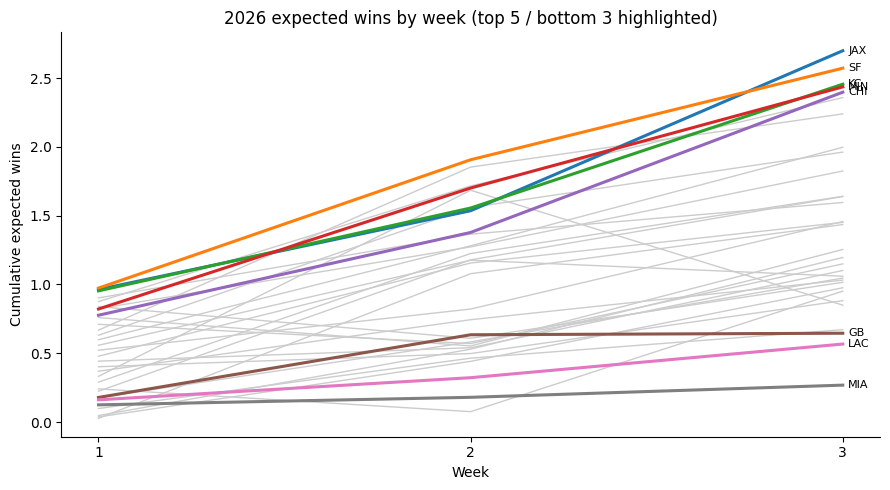

In [12]:
# Expected wins by week: cumulative expected wins, top and bottom teams highlighted
piv = cum.pivot(index="week", columns="team", values="exp_w")
order = now.sort_values("exp_w", ascending=False).team.tolist()
hi = order[:5] + order[-3:]
fig, ax = plt.subplots(figsize=(9, 5))
for tm in piv.columns:
    ax.plot(piv.index, piv[tm], color="#cccccc", lw=1)
for tm in hi:
    ax.plot(piv.index, piv[tm], lw=2.2, label=tm)
    ax.annotate(tm, (piv.index[-1], piv[tm].iloc[-1]), xytext=(4, 0), textcoords="offset points", fontsize=8, va="center")
ax.set(xlabel="Week", ylabel="Cumulative expected wins", title=f"{TRACK} expected wins by week (top 5 / bottom 3 highlighted)")
ax.set_xticks(piv.index); plt.tight_layout(); plt.show()

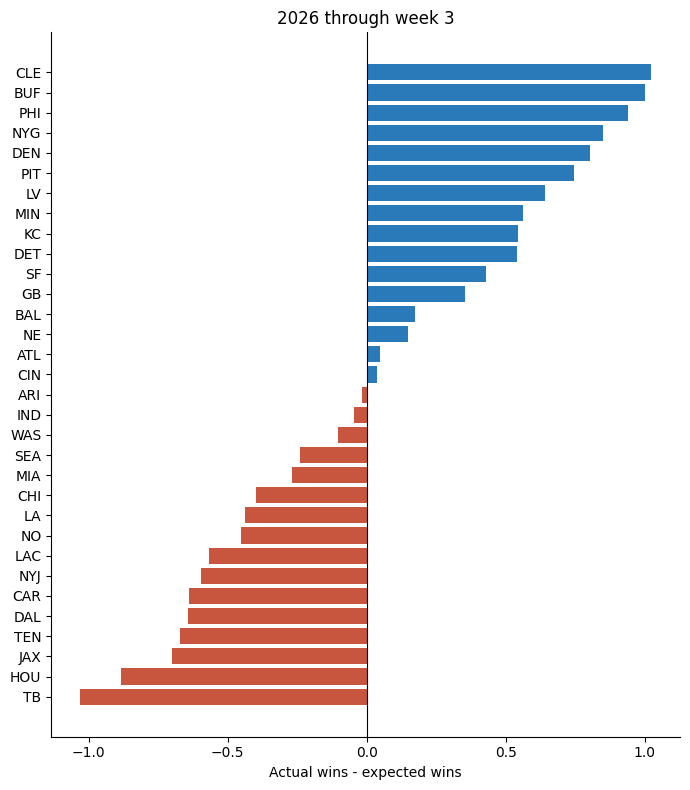

In [13]:
# Who is over/under-performing their point differential this week?
g = now.sort_values("gap")
fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(g.team, g.gap, color=np.where(g.gap >= 0, "#2a7ab9", "#c8553d"))
ax.axvline(0, color="k", lw=.8)
ax.set(xlabel="Actual wins - expected wins", title=f"{TRACK} through week {last_week}")
plt.tight_layout(); plt.show()

In [14]:
# Week-by-week table (expected wins), exportable
weekly = piv.round(2).T.sort_values(last_week, ascending=False)
weekly.to_csv(f"expected_wins_{TRACK}.csv")
weekly

week,1,2,3
team,,,
JAX,0.96,1.54,2.70
SF,0.97,1.91,2.57
KC,0.95,1.56,2.46
MIN,0.82,1.70,2.44
CHI,0.78,1.38,2.40
LV,0.88,1.72,2.36
SEA,0.67,1.85,2.24
BUF,0.60,1.28,2.00
CIN,0.63,1.56,1.96


## 10. Baseline game win probability (Pythagorean rating)
Each team gets a rating `r = k · log(PF/PA)` (the Pythagorean logit) from its season-to-date scoring, shrunk toward the league average by adding `n0` pseudo-games of an average team (so 3 games don't produce wild ratings).
Then `P(home win) = sigmoid(a + b · (r_home − r_away))`, where `a` is home-field advantage. `n0`, `a`, `b` are fit on 1999–2019 games and checked on 2020–2025.

In [15]:
LG = long.pf.mean()   # league-average points per team-game

def pregame_ratings(g, n0):
    """Rating of home and away team going into each game, using only earlier weeks of that season."""
    h = g.assign(team=g.home_team, pf=g.home_score, pa=g.away_score, side="home")
    a = g.assign(team=g.away_team, pf=g.away_score, pa=g.home_score, side="away")
    L = pd.concat([h, a]).sort_values(["season", "week"]).reset_index()
    # accumulate through the previous *week* (games in the same week never see each other)
    wk_tot = L.groupby(["season", "team", "week"], as_index=False)[["pf", "pa"]].sum()
    wk_tot["gp"] = L.groupby(["season", "team", "week"]).size().values
    cum = wk_tot.groupby(["season", "team"])[["pf", "pa", "gp"]].cumsum() - wk_tot[["pf", "pa", "gp"]]
    wk_tot[["cpf", "cpa", "cgp"]] = cum.values
    L = L.merge(wk_tot[["season", "team", "week", "cpf", "cpa", "cgp"]], on=["season", "team", "week"])
    L["r"] = K * np.log(((L.cpf + n0 * LG) / (L.cgp + n0)) / ((L.cpa + n0 * LG) / (L.cgp + n0)))
    out = L.pivot(index="index", columns="side", values="r")
    return out["home"], out["away"]

def design(g, n0):
    rh, ra = pregame_ratings(g, n0)
    return pd.DataFrame({"d": (rh - ra).reindex(g.index)}, index=g.index)

ghist = games.copy()
ghist["home_win"] = (ghist.home_score > ghist.away_score) + 0.5 * (ghist.home_score == ghist.away_score)
gtr, gte = ghist[ghist.season <= 2019], ghist[ghist.season >= 2020]

def fit_win(g, n0):
    return sm.GLM(g.home_win, sm.add_constant(design(g, n0)), family=sm.families.Binomial()).fit()

def logloss(m, g, n0):
    p = m.predict(sm.add_constant(design(g, n0)))
    return -np.mean(g.home_win * np.log(p) + (1 - g.home_win) * np.log(1 - p))

rows = [(n0, logloss(fit_win(gtr, n0), gtr, n0)) for n0 in [1, 2, 4, 6, 8, 12, 16]]
grid_ll = pd.DataFrame(rows, columns=["n0", "train log-loss"]).round(4)
N0 = int(grid_ll.loc[grid_ll["train log-loss"].idxmin(), "n0"])
gm = fit_win(gtr, N0)
print(grid_ll.to_string(index=False))
print(f"chosen n0 = {N0}; home-field a = {gm.params['const']:.3f} (= {1/(1+np.exp(-gm.params['const'])):.1%} for equal teams); scale b = {gm.params['d']:.3f}")

 n0  train log-loss
  1          0.6403
  2          0.6380
  4          0.6364
  6          0.6359
  8          0.6358
 12          0.6358
 16          0.6359
chosen n0 = 8; home-field a = 0.330 (= 58.2% for equal teams); scale b = 1.191


In [16]:
# Out-of-sample check, 2020-2025
p = gm.predict(sm.add_constant(design(gte, N0)))
y = gte.home_win
brier = lambda p: np.mean((p - y) ** 2)
ll = lambda p: -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
base = gtr.home_win.mean()
pd.DataFrame({
    "Log-loss": [ll(p), ll(np.full(len(y), base)), ll(np.full(len(y), .5))],
    "Brier":    [brier(p), brier(np.full(len(y), base)), brier(np.full(len(y), .5))],
    "Accuracy (non-ties)": [((p > .5) == (y > .5))[y != .5].mean(), ((base > .5) == (y > .5))[y != .5].mean(), np.nan],
}, index=["Pythagorean model", "Home-field only", "Coin flip"]).round(4)

,Log-loss,Brier,Accuracy (non-ties)
Pythagorean model,0.6546,0.2310,0.6075
Home-field only,0.6934,0.2493,0.5342
Coin flip,0.6931,0.2492,NaN


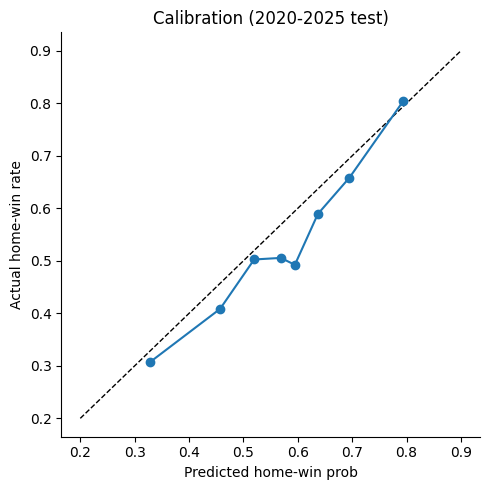

In [17]:
# calibration: predicted vs actual home-win rate by decile
cal = pd.DataFrame({"p": p, "y": y}); cal["bin"] = pd.qcut(cal.p, 8)
c = cal.groupby("bin", observed=True).agg(pred=("p", "mean"), actual=("y", "mean"), n=("y", "size"))
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([.2, .9], [.2, .9], "k--", lw=1); ax.plot(c.pred, c.actual, "o-")
ax.set(xlabel="Predicted home-win prob", ylabel="Actual home-win rate", title="Calibration (2020-2025 test)")
plt.tight_layout(); plt.show()

## 10b. Team-specific offense and defense ratings (used for the game predictions below)
The Pythagorean rating collapses a team into one number. Here each team gets two:
- **Offense** = points scored per game above the league average, and **Defense** = points allowed per game above average (positive = worse defense), each shrunk toward average with its own `n0` (defenses regress harder than offenses).
- A game's expected score is `home points = c0 + HFA + c_o·off_home + c_d·def_away` and `away points = c0 + c_o·off_away + c_d·def_home`; the coefficients and the shrinkage constants are fit on 1999–2019 by minimizing squared error on team-game scores.
- Win probability is `Φ(expected margin / SD)`. Section 11's simulation uses this same score model, so offense and defense update separately as simulated games are played.

In [18]:
from scipy.stats import norm

def pregame_cum(g):
    """Points for/against and games played by each team going into each game (earlier weeks of the same season only)."""
    h = g.assign(team=g.home_team, pf=g.home_score, pa=g.away_score, side="home")
    a = g.assign(team=g.away_team, pf=g.away_score, pa=g.home_score, side="away")
    L = pd.concat([h, a]).sort_values(["season", "week"]).reset_index()
    wk_ = L.groupby(["season", "team", "week"], as_index=False)[["pf", "pa"]].sum()
    wk_["gp"] = L.groupby(["season", "team", "week"]).size().values
    cm = wk_.groupby(["season", "team"])[["pf", "pa", "gp"]].cumsum() - wk_[["pf", "pa", "gp"]]
    wk_[["cpf", "cpa", "cgp"]] = cm.values
    L = L.merge(wk_[["season", "team", "week", "cpf", "cpa", "cgp"]], on=["season", "team", "week"])
    o = {}
    for c in ["cpf", "cpa", "cgp"]:
        pv = L.pivot(index="index", columns="side", values=c); o["h_" + c] = pv["home"]; o["a_" + c] = pv["away"]
    return pd.DataFrame(o).reindex(g.index)

def shrunk(pf, pa, gp, n_o, n_d):
    return (pf + n_o * LG) / (gp + n_o) - LG, (pa + n_d * LG) / (gp + n_d) - LG     # offense, defense (pts/game vs average)

Cg = pregame_cum(ghist)
trn = (ghist.season <= 2019).values

def fit_od(n_o, n_d):
    oh, dh = shrunk(Cg.h_cpf, Cg.h_cpa, Cg.h_cgp, n_o, n_d); oa, da = shrunk(Cg.a_cpf, Cg.a_cpa, Cg.a_cgp, n_o, n_d)
    y_ = np.r_[ghist.home_score.values, ghist.away_score.values]
    X_ = pd.DataFrame({"home": np.r_[np.ones(len(ghist)), np.zeros(len(ghist))],
                       "off": np.r_[oh.values, oa.values], "def": np.r_[da.values, dh.values]})
    m_ = np.r_[trn, trn]
    return sm.OLS(y_[m_], sm.add_constant(X_[m_])).fit()

rows = [(n_o, n_d, np.mean(fit_od(n_o, n_d).resid ** 2)) for n_o in [2, 4, 8, 12, 16] for n_d in [4, 8, 12, 16, 24]]
grid_od = pd.DataFrame(rows, columns=["n0 offense", "n0 defense", "train MSE (pts^2)"])
N_O, N_D = grid_od.loc[grid_od["train MSE (pts^2)"].idxmin(), ["n0 offense", "n0 defense"]].astype(int)
od = fit_od(N_O, N_D)
C0, HOME, C_O, C_D = od.params.values
SD_PTS = od.resid.std()
print(grid_od.pivot(index="n0 offense", columns="n0 defense", values="train MSE (pts^2)").round(2))
print(f"chosen n0: offense {N_O}, defense {N_D};  c0={C0:.2f}  home-field={HOME:.2f} pts  c_off={C_O:.2f}  c_def={C_D:.2f}  score SD={SD_PTS:.2f}")

def od_pts(oh, dh, oa, da):
    return C0 + HOME + C_O * oh + C_D * da, C0 + C_O * oa + C_D * dh       # expected home, away points

oh, dh = shrunk(Cg.h_cpf, Cg.h_cpa, Cg.h_cgp, N_O, N_D); oa, da = shrunk(Cg.a_cpf, Cg.a_cpa, Cg.a_cgp, N_O, N_D)
mh_, ma_ = od_pts(oh, dh, oa, da)
SD_M = (ghist.home_score - ghist.away_score - (mh_ - ma_))[trn].std()      # residual margin SD
print(f"residual margin SD = {SD_M:.2f}")

n0 defense     4      8      12     16     24
n0 offense                                   
2           95.70  95.69  95.70  95.71  95.73
4           95.61  95.61  95.62  95.63  95.65
8           95.65  95.65  95.67  95.68  95.70
12          95.72  95.72  95.74  95.75  95.77
16          95.78  95.78  95.80  95.81  95.84
chosen n0: offense 4, defense 8;  c0=20.79  home-field=2.53 pts  c_off=0.81  c_def=0.73  score SD=9.78
residual margin SD = 13.81


In [19]:
# Compare against the Pythagorean win-probability model on the 2020-2025 test games
p_od = pd.Series(norm.cdf((mh_ - ma_) / SD_M), index=ghist.index)[gte.index]
pd.DataFrame({
    "Log-loss": [ll(p_od), ll(p), ll(np.full(len(y), base)), ll(np.full(len(y), .5))],
    "Brier":    [brier(p_od), brier(p), brier(np.full(len(y), base)), brier(np.full(len(y), .5))],
    "Accuracy (non-ties)": [((p_od > .5) == (y > .5))[y != .5].mean(), ((p > .5) == (y > .5))[y != .5].mean(),
                            ((base > .5) == (y > .5))[y != .5].mean(), np.nan],
}, index=["Offense/defense model", "Pythagorean model", "Home-field only", "Coin flip"]).round(4)

,Log-loss,Brier,Accuracy (non-ties)
Offense/defense model,0.6540,0.2306,0.5957
Pythagorean model,0.6546,0.2310,0.6075
Home-field only,0.6934,0.2493,0.5342
Coin flip,0.6931,0.2492,NaN


In [20]:
# Current offense / defense ratings for the in-progress season
end = cum[cum.week == last_week].set_index("team")
off_s, def_s = shrunk(end.pf, end.pa, end.gp, N_O, N_D)
od_now = pd.DataFrame({"Team": end.index, "GP": end.gp.values,
                       "PF/g": (end.pf / end.gp).values.round(1), "PA/g": (end.pa / end.gp).values.round(1),
                       "Offense": (C_O * off_s).values, "Defense": (-C_D * def_s).values})   # both: points/game vs average, positive = good
od_now["Net"] = od_now.Offense + od_now.Defense
od_now = od_now.sort_values("Net", ascending=False).reset_index(drop=True)
od_now.round(2)

,Team,GP,PF/g,PA/g,Offense,Defense,Net
0,SF,3,32.7,16.7,3.66,1.08,4.74
1,JAX,3,27.3,12.0,1.82,2.02,3.83
2,KC,3,29.3,16.7,2.51,1.08,3.59
3,CHI,3,29.7,17.7,2.62,0.88,3.51
4,LV,3,29.3,18.0,2.51,0.82,3.32
5,BUF,3,33.7,26.0,4.01,-0.78,3.22
6,MIN,3,23.7,13.7,0.55,1.68,2.23
7,BAL,3,30.7,26.0,2.97,-0.78,2.19
8,SEA,3,25.0,16.7,1.01,1.08,2.09
9,CIN,3,26.7,21.0,1.59,0.22,1.80


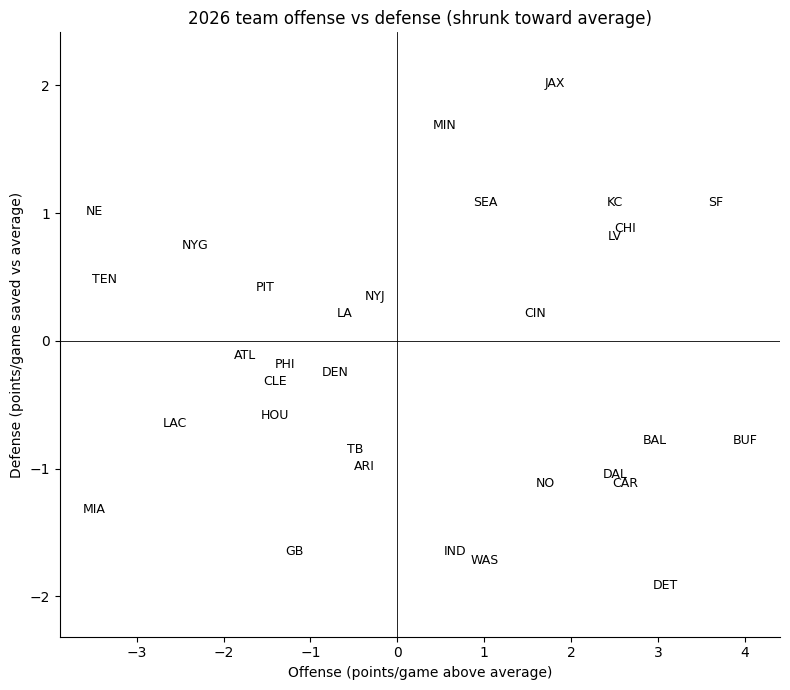

In [21]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.axhline(0, color="k", lw=.6); ax.axvline(0, color="k", lw=.6)
ax.scatter(od_now.Offense, od_now.Defense, s=0)
for _, r_ in od_now.iterrows():
    ax.annotate(r_.Team, (r_.Offense, r_.Defense), ha="center", va="center", fontsize=9)
ax.set(xlabel="Offense (points/game above average)", ylabel="Defense (points/game saved vs average)",
       title=f"{TRACK} team offense vs defense (shrunk toward average)")
pad = 0.4; ax.set_xlim(od_now.Offense.min() - pad, od_now.Offense.max() + pad); ax.set_ylim(od_now.Defense.min() - pad, od_now.Defense.max() + pad)
plt.tight_layout(); plt.show()

In [22]:
# Next game for every team in the in-progress season (offense/defense model)
sched = nfl.import_schedules([TRACK])
sched = sched[sched.game_type == "REG"].copy()
upcoming = sched[sched.home_score.isna() | sched.away_score.isna()]

unplayed = upcoming[["season", "week", "home_team", "away_team"]].copy()
# every future game is scored with ratings as of the latest completed week
ph_, pa__ = od_pts(unplayed.home_team.map(off_s), unplayed.home_team.map(def_s), unplayed.away_team.map(off_s), unplayed.away_team.map(def_s))
unplayed["pts_home"], unplayed["pts_away"] = ph_, pa__
unplayed["p_home"] = norm.cdf((ph_ - pa__) / SD_M)

hm = unplayed.assign(team=unplayed.home_team, opp=unplayed.away_team, at="vs", win_prob=unplayed.p_home, pts=unplayed.pts_home, opp_pts=unplayed.pts_away)
aw = unplayed.assign(team=unplayed.away_team, opp=unplayed.home_team, at="@", win_prob=1 - unplayed.p_home, pts=unplayed.pts_away, opp_pts=unplayed.pts_home)
nxt_g = (pd.concat([hm, aw]).sort_values(["team", "week"]).groupby("team").head(1))
nxt_g["Next game"] = nxt_g["at"] + " " + nxt_g.opp
nxt_g["Pred score"] = nxt_g.pts.round(1).astype(str) + " - " + nxt_g.opp_pts.round(1).astype(str)
nxt_g["Offense"] = nxt_g.team.map(C_O * off_s).round(2); nxt_g["Defense"] = nxt_g.team.map(-C_D * def_s).round(2)
out = nxt_g[["team", "week", "Next game", "win_prob", "Pred score", "Offense", "Defense"]].rename(columns={"team": "Team", "week": "Week", "win_prob": "Win prob"})
out = out.sort_values("Win prob", ascending=False).reset_index(drop=True)
out["Win prob"] = (out["Win prob"] * 100).round(1)
out.to_csv(f"next_game_win_prob_{TRACK}.csv", index=False)
out

,Team,Week,Next game,Win prob,Pred score,Offense,Defense
0,MIN,4,vs MIA,75.6,25.2 - 15.6,0.55,1.68
1,SF,4,vs DEN,72.5,27.2 - 19.0,3.66,1.08
2,BUF,4,vs NE,72.4,26.3 - 18.1,4.01,-0.78
3,SEA,4,vs LAC,71.5,25.0 - 17.1,1.01,1.08
4,BAL,4,vs TEN,70.9,25.8 - 18.2,2.97,-0.78
5,CHI,4,vs NYJ,66.7,25.6 - 19.7,2.62,0.88
6,NO,4,vs ATL,64.1,25.1 - 20.2,1.70,-1.12
7,TB,4,vs GB,61.5,24.5 - 20.5,-0.49,-0.85
8,CAR,4,vs DET,58.2,27.9 - 25.0,2.62,-1.12
9,WAS,4,vs IND,58.1,26.0 - 23.2,1.01,-1.72


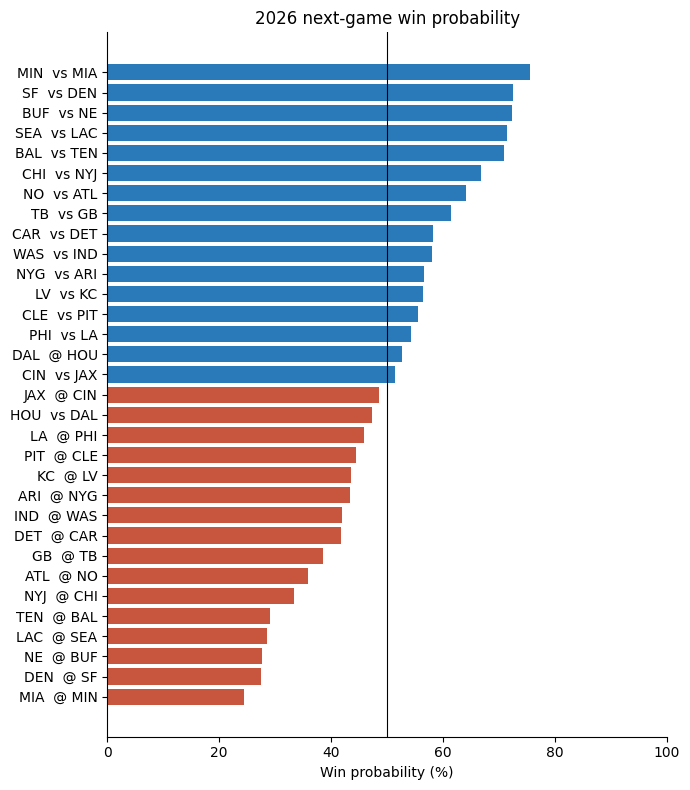

In [23]:
fig, ax = plt.subplots(figsize=(7, 8))
o = out.sort_values("Win prob")
ax.barh(o.Team + "  " + o["Next game"], o["Win prob"], color=np.where(o["Win prob"] >= 50, "#2a7ab9", "#c8553d"))
ax.axvline(50, color="k", lw=.8); ax.set(xlim=(0, 100), xlabel="Win probability (%)", title=f"{TRACK} next-game win probability")
plt.tight_layout(); plt.show()

## 11. Full-season predictions: every regular-season matchup
Every game gets an expected score (from the offense/defense model) and a home-win probability. Played games use each team's ratings going into that week (what the model would have said then); unplayed games use ratings as of the latest completed week.
Simulating the remaining games 20,000 times gives projected final records.

In [24]:
full = sched[["season", "week", "gameday", "home_team", "away_team", "home_score", "away_score"]].copy()
played = full.home_score.notna() & full.away_score.notna()

# played games: pre-game offense/defense from earlier weeks only
Cc = pregame_cum(cg)
o_h, d_h = shrunk(Cc.h_cpf, Cc.h_cpa, Cc.h_cgp, N_O, N_D); o_a, d_a = shrunk(Cc.a_cpf, Cc.a_cpa, Cc.a_cgp, N_O, N_D)
pth, pta = od_pts(o_h, d_h, o_a, d_a)
full.loc[played, "pts_home"] = pth.reindex(full.index[played]).values; full.loc[played, "pts_away"] = pta.reindex(full.index[played]).values
# unplayed games: ratings as of the latest completed week
uh = full.loc[~played, "home_team"]; ua = full.loc[~played, "away_team"]
full.loc[~played, "pts_home"], full.loc[~played, "pts_away"] = od_pts(uh.map(off_s), uh.map(def_s), ua.map(off_s), ua.map(def_s))
full["p_home"] = norm.cdf((full.pts_home - full.pts_away) / SD_M)

full["status"] = np.where(played, "final", "predicted")
full["pick"] = np.where(full.p_home >= .5, full.home_team, full.away_team)
full["pick_prob"] = np.maximum(full.p_home, 1 - full.p_home)
full["result"] = np.where(~played, "", np.where(full.home_score > full.away_score, full.home_team,
                          np.where(full.home_score < full.away_score, full.away_team, "TIE")))
sched_out = full.sort_values(["week", "gameday", "home_team"]).reset_index(drop=True)
sched_out.to_csv(f"season_predictions_{TRACK}.csv", index=False)

hit = sched_out[sched_out.status == "final"]
hit = hit[hit.result != "TIE"]
print(f"{len(sched_out)} games: {(sched_out.status=='final').sum()} played, {(sched_out.status=='predicted').sum()} predicted")
print(f"Pre-game picks on played games so far: {(hit.pick == hit.result).mean():.1%} ({(hit.pick == hit.result).sum()}/{len(hit)})")
sched_out.assign(home_win_pct=(sched_out.p_home * 100).round(1))[
    ["week", "gameday", "away_team", "home_team", "pts_away", "pts_home", "home_win_pct", "pick", "status", "result"]].round(1)

272 games: 48 played, 224 predicted
Pre-game picks on played games so far: 54.2% (26/48)


,week,gameday,away_team,home_team,pts_away,pts_home,home_win_pct,pick,status,result
0,1,2026-09-09,NE,SEA,20.8,23.3,57.3,SEA,final,SEA
1,1,2026-09-10,SF,LA,20.8,23.3,57.3,LA,final,SF
2,1,2026-09-13,CHI,CAR,20.8,23.3,57.3,CAR,final,CHI
3,1,2026-09-13,TB,CIN,20.8,23.3,57.3,CIN,final,CIN
4,1,2026-09-13,NO,DET,20.8,23.3,57.3,DET,final,DET
...,...,...,...,...,...,...,...,...,...,...
267,18,2027-01-10,CHI,MIN,21.7,23.0,53.6,MIN,predicted,
268,18,2027-01-10,MIA,NE,16.3,21.2,63.8,NE,predicted,
269,18,2027-01-10,TB,NO,21.4,25.9,62.7,NO,predicted,
270,18,2027-01-10,PHI,NYG,18.7,21.2,57.0,NYG,predicted,


### Season simulation with week-by-week rating updates
Each remaining game is simulated week by week. Before a week is played, every team's **offense and defense** are recomputed from its points for/against so far in that simulated season (real games plus simulated ones). Each team's score is then drawn as `Normal(expected points, SD)` from the offense/defense score model, so a team's offense and defense drift independently. A static-ratings run is kept for comparison.

In [25]:
from scipy.stats import norm

teams = sorted(set(full.home_team) | set(full.away_team))
ti = {t_: i for i, t_ in enumerate(teams)}
info = nfl.import_team_desc().set_index("team_abbr").loc[teams]
conf = info.team_conf.values; div = info.team_division.values
tconf = pd.Series(conf, index=teams); tdiv = pd.Series(div, index=teams)

# division / conference wins from games already played (ties = half a win)
cur_d = np.zeros(len(teams)); cur_c = np.zeros(len(teams))
for _, r in full[played].iterrows():
    hw = 1.0 if r.home_score > r.away_score else 0.5 if r.home_score == r.away_score else 0.0
    for tm, w in ((r.home_team, hw), (r.away_team, 1 - hw)):
        opp = r.away_team if tm == r.home_team else r.home_team
        if tdiv[tm] == tdiv[opp]: cur_d[ti[tm]] += w
        if tconf[tm] == tconf[opp]: cur_c[ti[tm]] += w

end = now.set_index("team").reindex(teams)
init = dict(pf=end.pf.values, pa=end.pa.values, gp=end.gp.values, w=end.w.values, dw=cur_d, cw=cur_c)

todo = full[~played].copy()
todo["hi"] = todo.home_team.map(ti); todo["ai"] = todo.away_team.map(ti)
todo["is_div"] = todo.home_team.map(tdiv) == todo.away_team.map(tdiv)
todo["is_conf"] = todo.home_team.map(tconf) == todo.away_team.map(tconf)

print(f"score model: expected pts from offense/defense, each team's score SD {SD_PTS:.1f}")

def simulate(dynamic, nsim=20000, seed=42):
    rng = np.random.default_rng(seed)
    S = {k: np.tile(v.astype(float), (nsim, 1)) for k, v in init.items()}
    o0, d0 = shrunk(init["pf"], init["pa"], init["gp"], N_O, N_D)
    o0 = np.tile(o0, (nsim, 1)); d0 = np.tile(d0, (nsim, 1))
    for wk_ in sorted(todo.week.unique()):
        O, D = shrunk(S["pf"], S["pa"], S["gp"], N_O, N_D) if dynamic else (o0, d0)   # ratings going into this week
        for g_ in todo[todo.week == wk_].itertuples():
            h, a = g_.hi, g_.ai
            mu_h, mu_a = od_pts(O[:, h], D[:, h], O[:, a], D[:, a])
            ph = np.clip(mu_h + SD_PTS * rng.standard_normal(nsim), 0, None)
            pa_ = np.clip(mu_a + SD_PTS * rng.standard_normal(nsim), 0, None)
            hw = ph > pa_
            S["pf"][:, h] += ph; S["pa"][:, h] += pa_; S["pf"][:, a] += pa_; S["pa"][:, a] += ph
            S["gp"][:, [h, a]] += 1
            S["w"][:, h] += hw; S["w"][:, a] += ~hw
            if g_.is_div: S["dw"][:, h] += hw; S["dw"][:, a] += ~hw
            if g_.is_conf: S["cw"][:, h] += hw; S["cw"][:, a] += ~hw
    return S

dyn = simulate(True); stat = simulate(False)
tot, dw, cw = dyn["w"], dyn["dw"], dyn["cw"]
nsim = tot.shape[0]; cur_w = init["w"]

proj = pd.DataFrame({
    "Team": teams,
    "W now": cur_w,
    "Proj W": tot.mean(0),
    "10th pct": np.percentile(tot, 10, axis=0),
    "90th pct": np.percentile(tot, 90, axis=0),
    "P(10+ W)": (tot >= 10).mean(0),
    "P(<=6 W)": (tot <= 6).mean(0),
    "P(best record)": (tot == tot.max(1, keepdims=True)).mean(0),
    "Proj W (static)": stat["w"].mean(0),
    "Win SD": tot.std(0),
    "Win SD (static)": stat["w"].std(0),
})
proj["Proj L"] = 17 - proj["Proj W"]   # ignores the rare tie
proj = proj.sort_values("Proj W", ascending=False).reset_index(drop=True)
proj.round(3).to_csv(f"projected_records_{TRACK}.csv", index=False)
print(f"Avg SD of season wins: {proj['Win SD'].mean():.2f} (week-by-week updates) vs {proj['Win SD (static)'].mean():.2f} (static ratings)")
proj[["Team", "W now", "Proj W", "Proj W (static)", "10th pct", "90th pct", "P(10+ W)", "P(<=6 W)", "P(best record)"]].round(2)

score model: expected pts from offense/defense, each team's score SD 9.8


Avg SD of season wins: 2.28 (week-by-week updates) vs 1.82 (static ratings)


,Team,W now,Proj W,Proj W (static),10th pct,90th pct,P(10+ W),P(<=6 W),P(best record)
0,SF,3.0,11.48,11.76,9.0,14.0,0.81,0.01,0.22
1,LV,3.0,11.01,11.19,8.0,14.0,0.75,0.03,0.17
2,BUF,3.0,10.99,11.22,8.0,14.0,0.74,0.03,0.16
3,MIN,3.0,10.96,10.96,8.0,14.0,0.74,0.03,0.16
4,KC,3.0,10.83,11.08,8.0,14.0,0.72,0.03,0.15
5,JAX,2.0,10.38,10.56,7.0,13.0,0.66,0.05,0.10
6,CHI,2.0,10.26,10.38,7.0,13.0,0.64,0.05,0.09
7,BAL,2.0,9.89,9.99,7.0,13.0,0.57,0.07,0.07
8,DET,2.0,9.71,9.71,7.0,13.0,0.54,0.08,0.06
9,CIN,2.0,9.69,9.79,7.0,13.0,0.54,0.09,0.06


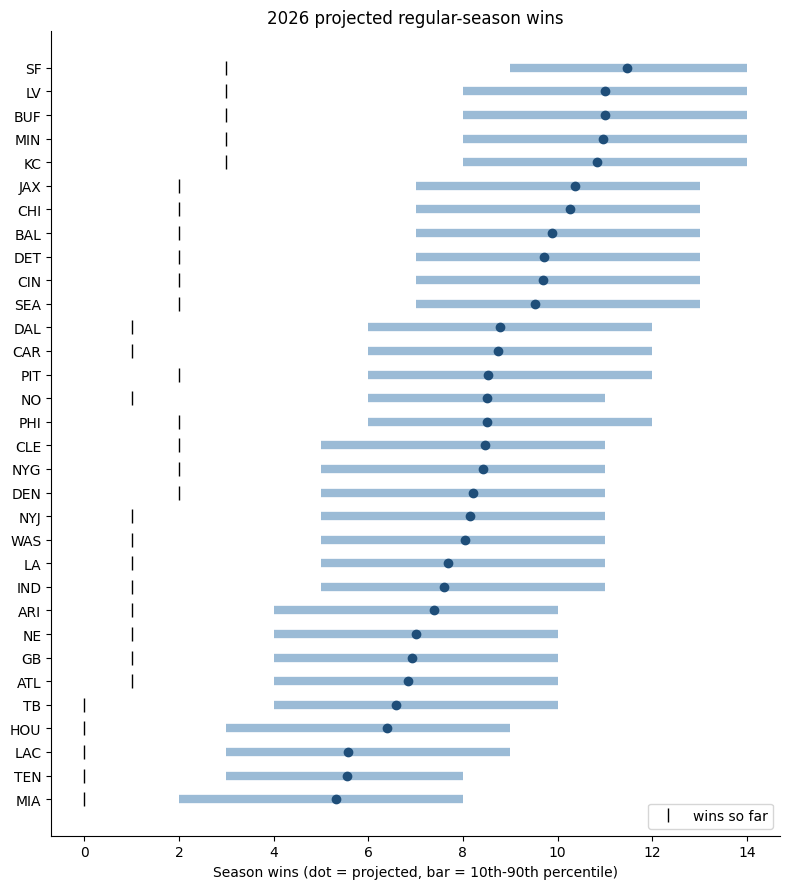

In [26]:
fig, ax = plt.subplots(figsize=(8, 9))
p_ = proj.iloc[::-1]
ax.hlines(p_.Team, p_["10th pct"], p_["90th pct"], color="#9bbbd6", lw=6)
ax.plot(p_["Proj W"], p_.Team, "o", color="#1f4e79")
ax.plot(p_["W now"], p_.Team, "|", color="k", ms=10, label="wins so far")
ax.set(xlabel="Season wins (dot = projected, bar = 10th-90th percentile)", title=f"{TRACK} projected regular-season wins")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 12. Playoff seeding simulation
Reuses the 20,000 simulated seasons (week-by-week rating updates) from section 11 and seeds 7 teams per conference: 4 division winners (seeds 1-4, by record) and 3 wild cards (seeds 5-7).
**Tiebreakers are simplified**: wins, then division record (to pick division winners) or conference record (wild cards), then a coin flip. The real NFL procedure (head-to-head, common opponents, strength of victory, etc.) isn't modeled, so treat close calls as approximate.

In [27]:
rng = np.random.default_rng(7)
rnd = rng.random((nsim, len(teams)))
key_div = tot * 1e4 + dw * 1e2 + cw + rnd * .9      # division winner: wins, div record, conf record, coin flip
key_wc  = tot * 1e4 + cw * 1e2 + dw + rnd * .9      # wild card: wins, conf record, div record, coin flip

seed = np.zeros((nsim, len(teams)), dtype=int)       # 0 = missed playoffs, 1-7 = seed
divwin = np.zeros((nsim, len(teams)), dtype=bool)
rows_ = np.arange(nsim)
for c in ["AFC", "NFC"]:
    winners = []
    for d_ in sorted({x for x in div if x.startswith(c)}):
        idx = np.where(div == d_)[0]
        w_ = idx[np.argmax(key_div[:, idx], axis=1)]
        divwin[rows_, w_] = True; winners.append(w_)
    W = np.stack(winners, 1)                                    # (nsim, 4) team idx of division winners
    order = np.argsort(-np.take_along_axis(key_wc, W, 1), axis=1)
    W = np.take_along_axis(W, order, 1)
    for s_ in range(4): seed[rows_, W[:, s_]] = s_ + 1
    cidx = np.where(conf == c)[0]
    kk = key_wc[:, cidx].copy(); kk[divwin[:, cidx]] = -1        # exclude division winners
    top3 = np.argsort(-kk, axis=1)[:, :3]
    for s_ in range(3): seed[rows_, cidx[top3[:, s_]]] = 5 + s_

po = pd.DataFrame({"Team": teams, "Conf": conf, "Division": div, "Proj W": tot.mean(0),
    "P(playoffs)": (seed > 0).mean(0), "P(win division)": divwin.mean(0), "P(#1 seed, bye)": (seed == 1).mean(0),
    **{f"P(seed {s_})": (seed == s_).mean(0) for s_ in range(1, 8)}, "Avg seed | playoffs": [seed[seed[:, i] > 0, i].mean() if (seed[:, i] > 0).any() else np.nan for i in range(len(teams))]})
po = po.sort_values(["Conf", "P(playoffs)"], ascending=[True, False]).reset_index(drop=True)
po.round(3).to_csv(f"playoff_odds_{TRACK}.csv", index=False)
print("Mean playoff teams per sim:", (seed > 0).sum(1).mean(), "(should be 14)")
po[["Team", "Division", "Proj W", "P(playoffs)", "P(win division)", "P(#1 seed, bye)", "Avg seed | playoffs"]].round(3)

Mean playoff teams per sim: 14.0 (should be 14)


,Team,Division,Proj W,P(playoffs),P(win division),"P(#1 seed, bye)",Avg seed | playoffs
0,BUF,AFC East,10.994,0.818,0.679,0.199,2.979
1,LV,AFC West,11.013,0.807,0.466,0.206,3.537
2,KC,AFC West,10.832,0.802,0.435,0.186,3.670
3,JAX,AFC South,10.378,0.780,0.682,0.119,3.199
4,BAL,AFC North,9.892,0.660,0.370,0.096,3.948
5,CIN,AFC North,9.688,0.605,0.290,0.069,4.271
6,NYJ,AFC East,8.156,0.427,0.194,0.028,4.580
7,PIT,AFC North,8.535,0.422,0.175,0.027,4.692
8,CLE,AFC North,8.458,0.380,0.164,0.026,4.638
9,DEN,AFC West,8.203,0.357,0.086,0.022,5.139


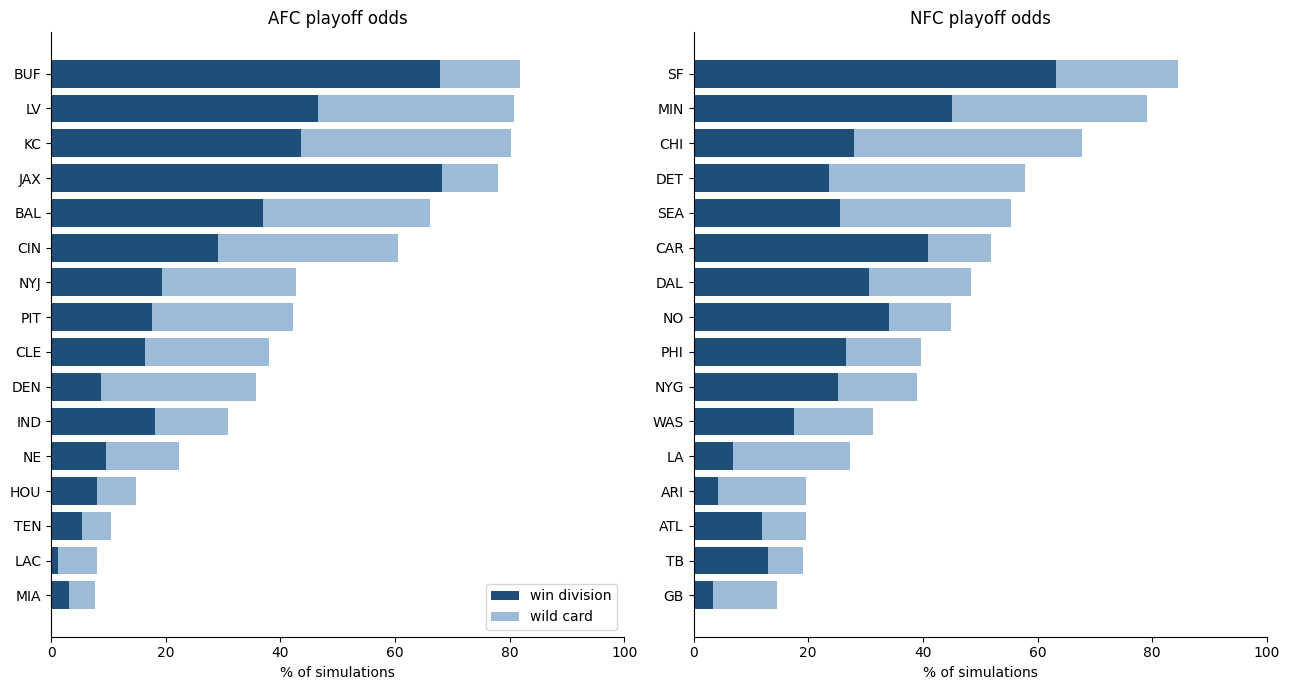

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(13, 7), sharex=True)
for ax, c in zip(axs, ["AFC", "NFC"]):
    d = po[po.Conf == c].sort_values("P(playoffs)")
    ax.barh(d.Team, d["P(win division)"] * 100, color="#1f4e79", label="win division")
    ax.barh(d.Team, (d["P(playoffs)"] - d["P(win division)"]) * 100, left=d["P(win division)"] * 100, color="#9bbbd6", label="wild card")
    ax.set(title=f"{c} playoff odds", xlabel="% of simulations", xlim=(0, 100))
axs[0].legend(loc="lower right"); plt.tight_layout(); plt.show()

In [29]:
# Most likely bracket: fill seeds 1-7 in order, each with the most likely team not already placed
for c in ["AFC", "NFC"]:
    d = po[po.Conf == c]; used = set(); print(c)
    for s_ in range(1, 8):
        r = d[~d.Team.isin(used)].sort_values(f"P(seed {s_})", ascending=False).iloc[0]
        used.add(r.Team)
        print(f"  seed {s_}: {r.Team:>3}  ({r[f'P(seed {s_})']:.0%})")

AFC
  seed 1:  LV  (21%)
  seed 2: BUF  (17%)
  seed 3: JAX  (18%)
  seed 4: IND  (10%)
  seed 5:  KC  (19%)
  seed 6: CIN  (12%)
  seed 7: DEN  (9%)
NFC
  seed 1:  SF  (28%)
  seed 2: MIN  (14%)
  seed 3: CAR  (12%)
  seed 4:  NO  (15%)
  seed 5: CHI  (18%)
  seed 6: DET  (11%)
  seed 7: SEA  (9%)
